# Fast Example: E/S Analysis

When you have Donor and Acceptor excitaiton ($\mu sALEX$, or $PIE$/$ns ALEX$),
The most common analysis is E/S plots, examining the ratios of different channels to one another.

We start with the basic imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.datamodel.multifit as smfit

Now load the data, and regularize the detectors 
(use metadata to assign raw detector indexes to specific spectral channels, as well as excitations)

In [2]:
raw = smf.photonHDF5.load('data/dsdna_d7_d17_50_50_1.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

## Burst Search Parameters

The `smffretfactory` module provides a number of convenience functions that build dictionaries of related `Param` and `Column` objects.

The two functions used do the following:

1. `smf.fretfactory.make_bg`
   First we use `smf.fretfactory.make_bg` to define background analysis.\
   The `func` kwarg defines which background fitting function to use\
   The `tail_min` sets the minimum interphoton time to consider\
   The `auto_threshold` kwarg defines whether to fit with an optimized threshold for the interphoton time or `tail_min` directly\
   The `F_bg` sets the factor times the intial fit background rate to use when `auto_threshold` is True\

2. `smf.fretfactory.make_burst_search`
   Defines a burst search\
   The `streams` argument defines which stream(s) to include, if multiple are specified, will use an and gate between them\
   The `m` argument defines the size of the slideing window\
   The `F` argument defines the number of times the background rate the signal must be in order to be considered a burst

Finally, you will want to set some reasonable burst size thresholds, here we set it at 30 for donor excitation, and 30 for acceptor excitation.
This ensures reasonable FRET signal.

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, tail_min=5e-4, auto_threshold=True, F_bg=2.0)
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), m=10, F=6.0) # example of DCBS
gate = smf.make_geq_gate(dbs['NphDex_bg'], 30.0) & smf.make_geq_gate(dbs['NphAA_bg'], 30.0)

In [4]:
str(dbg['BgAll'].keytup[0])

'0ex_1em'

In [5]:
dbg.keys()

dict_keys(['periods', 'bg', 'BgDD', 'BgDA', 'BgAll', 'BgAA'])

In [6]:
times = data.times
dets = data.dets
dset = np.array([0,1,3], dtype=np.uint8)
bg = data.get_column(dbg['BgAll'])
prd = data.get_column(smf.Column(dbg['periods'], 'periods'))

In [7]:
times.tofile('times.dat')

In [8]:
dets.tofile('dets.dat')

## Plotting

Now we can visualize.
The `smf.plot.jointplot()` makes it easy to plot both a scatter plot and histograms of a pair of `Columns`.
kwargs can be passed to the subplots using the `cplot_kwargs` (for center plot), and `hplot_kwargs` (for histogram plots)
in order to customize the plots.
Note that we use the `smf.fretfactory.ALEXdefaults` object to get some default arguments for these,
as though we were calling `smf.plot.scatter()` and `smf.plot.hist_bar()`
Creating the `fig` before allows setting the size of the figure (note this is a figure, not an axes).
The kwargs `gridspec_kwargs` is used to remove the space between axes.

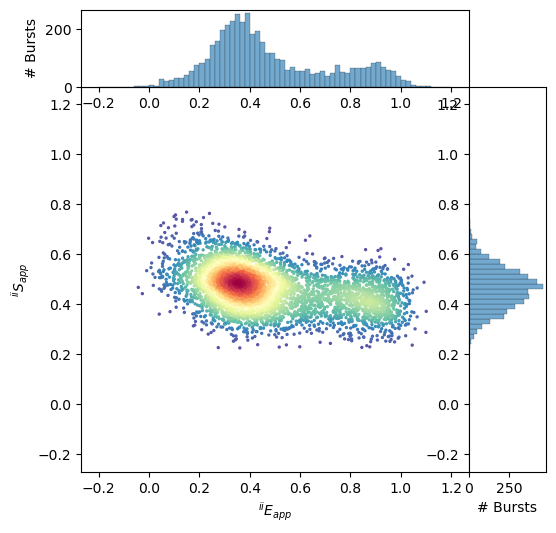

In [9]:
fig = plt.figure(figsize=(6,6))
axs, cout, xout, yout = smf.plot.jointplot(data, dbs['E_bg'], dbs['S_bg'], gate=gate, # note the ... before = is not useed in the rest of the tutorial
                                           cplot_kwargs=smf.fretfactory.ALEXdefaults['scatter',('point_func',smf.plot.density_kde),('cmap','Spectral_r')], 
                                           hplot_kwargs=smf.fretfactory.ALEXdefaults['histbar', ('bins', 'ratio_bins')],
                                           gridspec_kwargs={'hspace':0, 'wspace':0},
                                           fig=fig)

We can also just plot the scatter plot, which is useful in to be inserted into other more complex figure arrangements.

(-0.2, 1.2)

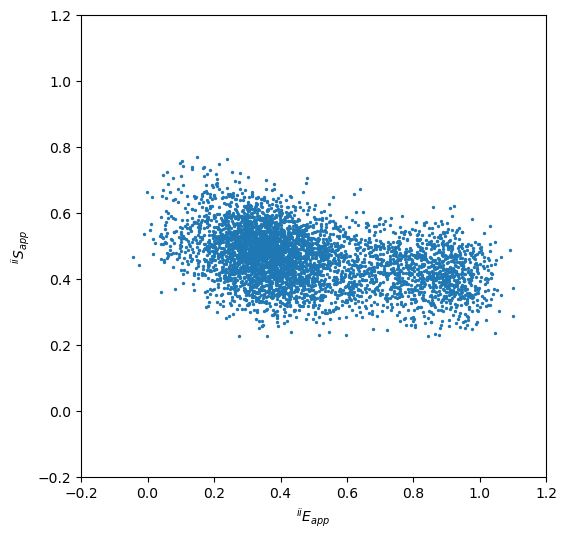

In [10]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['scatter'])
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

Or we can plot the hexbin with `smf.plot.hexbin` to visualize the data as a histogram.
This can be more useful when there are a very large number of bursts.

(<matplotlib.collections.PolyCollection at 0x7a3a7ee0bd10>,
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, '$^{ii}S_{app}$'))

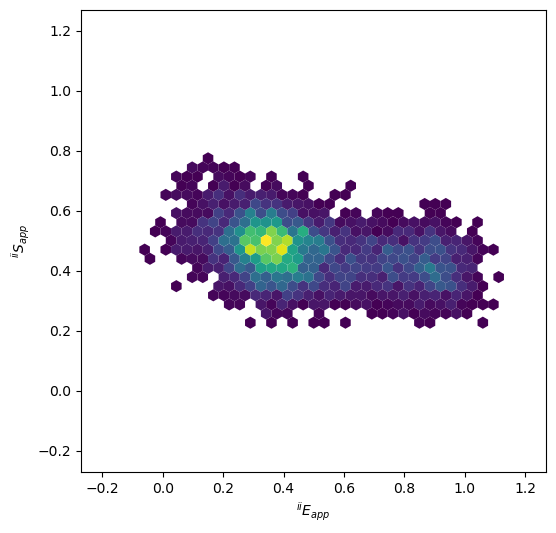

In [11]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
smf.plot.hexbin(data, dbs['E_bg'], dbs['S_bg'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['hexbin'])

## Publication recomendations


### Citations

Of course, after we are done we should remember to print out the citations wtih `smf.print_citations()` 
(or get them with `smf.get_citations()` instead for a more detailed list)

In [12]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).


### Print Params

It is also recomended to get descriptions of the parameters used for the analysis.

All `Param`, `Column`, and `GateGroup` objects have a `.description` property.
Printing this will generate a yaml-like string that is good to add to your supplementary data, as it exactly describes the object.

Since we always used the `gate` as our gate, we can fold the gate into the description with the `.regate()` method.
You should select at a minimum the key Columns used in your anlalysis.
Also note that this is a full description, so a `Column` description will include the description of the `Param` on which it is based.

In [13]:
print(dbs['nphbg'].regate(gate).description)

Table: NphBG
Params:
  single: True
Parents:
  base:
    Table: BurstOvlp
    Params:
      fuse: 0.0
      truthtable: [[False False]
                   [False  True]]
    Parents:
      bases:
        - Table: Bursts
          Params:
            func: smfbursts.bursttables.burstsearch_mwindowF_bg
            stream: 0ex
            m: 10
            F: 6.0
            c: -1.0
            fuse: 0.0
          Parents:
            bg:
              Table: BG
              Params:
                compute_stream: single_all
                func: smfbursts.backgroundtables.exp_mlefit
                tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
                auto_threshold: True
                F_bg: 2.0
              Parents:
                base:
                  Table: Periods
                  Params:
                    period: 60.0
                    start_at: time_min
                    stop_at: over
                    detdef: DetDef2ex2em  - Table: Bursts
          Params:


In this tutorial we used only one gate, if multiple gates are used, 
it is best to give all their descriptions separately.